In [1]:
#necessary imports
import numpy as np
import matplotlib.pyplot as plt

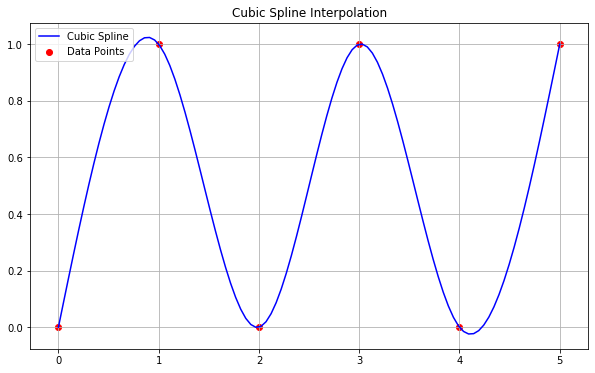

In [16]:
# Step 1: Define known data points
x = np.array([0, 1, 2, 3, 4, 5]) # Example data points provided in the homework materials
y = np.array([0, 1, 0, 1, 0, 1])

# Step 2: Calculate step sizes 
# hi = xi+1 - xi 
h = np.diff(x)
n = len(x)

# --- STEP 3: Set Up and Solve the Tridiagonal System ---
def setup_tridiagonal_matrix(x, y, h):
    n = len(x)
    # The system is for internal points M2 to Mn-1, so size is n-2 
    A = np.zeros(n - 3) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 3) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side
    
    for i in range(1, n - 1):
        idx = i - 1
        # Populate based on smoothness equations 
        if idx > 0:
            A[idx - 1] = h[i-1]
        B[idx] = 2 * (h[i-1] + h[i])
        if idx < n - 3:
            C[idx] = h[i]
        
        # RHS represents change in slopes
        D[idx] = 6 * ((y[i+1] - y[i])/h[i] - (y[i] - y[i-1])/h[i-1])
        
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    
    n_solve = len(b)
    # Forward elimination 
    for i in range(1, n_solve):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    
    # Back substitution [cite: 42, 43]
    sol = np.zeros(n_solve)
    sol[-1] = d[-1] / b[-1]
    for i in range(n_solve - 2, -1, -1):
        sol[i] = (d[i] - c[i] * sol[i+1]) / b[i]
    return sol

# Calculate A, B, C, D and solve for internal second derivatives M
A, B, C, D = setup_tridiagonal_matrix(x, y, h)
internal_M = thomas_algorithm(A, B, C, D)

# Add Natural Boundary Conditions: M1 = Mn = 0 
M = np.concatenate(([0], internal_M, [0]))

# Step 4: New spinal points 
def evaluate_spline(val, x, y, M, h):
    
    if val <= x[0]: return y[0]
    if val >= x[-1]: return y[-1]
    
    # Find the correct interval for the point 
    i = np.searchsorted(x, val) - 1
    
    # Use the second derivative formula to evaluate the spline 
    term1 = M[i] * (x[i+1] - val)**3 / (6 * h[i])
    term2 = M[i+1] * (val - x[i])**3 / (6 * h[i])
    term3 = (y[i]/h[i] - M[i]*h[i]/6) * (x[i+1] - val)
    term4 = (y[i+1]/h[i] - M[i+1]*h[i]/6) * (val - x[i])
    
    return term1 + term2 + term3 + term4

# Plotting results
# Create smooth points for plotting 
x_plot = np.linspace(x[0], x[-1], 100)
y_plot = [evaluate_spline(val, x, y, M, h) for val in x_plot]

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label='Cubic Spline', color='blue')
plt.scatter(x, y, color='red', label='Data Points') # Original data points 
plt.title('Cubic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()